# Example notebook

In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import vstack, QTable
import astropy.units as u
import pickle 
from importlib import reload
import re

# read in the data

In [2]:
# fix up custom units
gvis = u.def_unit('Gvis',namespace=globals())
u.add_enabled_units([gvis])

In [3]:
wsu_all = QTable.read('data/wsu_datarates_mit_per_mous_initial_goal_20250423.ecsv')

In [4]:
wsu_all['weights_all'] = wsu_all['time_tot']/np.sum(wsu_all['time_tot'])

In [5]:
wsu_all.columns

<TableColumns names=('mous','proposal_id','schedblock_name','array','science_keyword','scientific_category','scientific_category_proposal','nant_typical','nant_array','nant_all','band','ntarget','s_fov','s_resolution','mosaic','imsize','pb','cell','blc_npol','blc_nspw','blc_specwidth','blc_freq','blc_velres','blc_nchan_agg','blc_nchan_max','blc_bandwidth_max','blc_bandwidth_agg','wsu_freq','wsu_npol','wsu_bandwidth_early','wsu_bandwidth_later_2x','wsu_bandwidth_later_4x','wsu_bandwidth_spw','wsu_nspw_early','wsu_nspw_later_2x','wsu_nspw_later_4x','wsu_specwidth_finest','wsu_chanavg_finest','wsu_velres_finest','wsu_specwidth_stepped','wsu_chanavg_stepped','wsu_velres_stepped','wsu_specwidth_stepped2','wsu_chanavg_stepped2','wsu_velres_stepped2','wsu_tint','wsu_nchan_spw_finest','wsu_nchan_spw_stepped','wsu_nchan_spw_stepped2','wsu_nchan_agg_finest_early','wsu_nchan_agg_finest_later_2x','wsu_nchan_agg_finest_later_4x','wsu_nchan_agg_stepped_early','wsu_nchan_agg_stepped_later_2x','wsu_nc

In [6]:
len(wsu_all)

5192

In [7]:
wsu_all.columns

<TableColumns names=('mous','proposal_id','schedblock_name','array','science_keyword','scientific_category','scientific_category_proposal','nant_typical','nant_array','nant_all','band','ntarget','s_fov','s_resolution','mosaic','imsize','pb','cell','blc_npol','blc_nspw','blc_specwidth','blc_freq','blc_velres','blc_nchan_agg','blc_nchan_max','blc_bandwidth_max','blc_bandwidth_agg','wsu_freq','wsu_npol','wsu_bandwidth_early','wsu_bandwidth_later_2x','wsu_bandwidth_later_4x','wsu_bandwidth_spw','wsu_nspw_early','wsu_nspw_later_2x','wsu_nspw_later_4x','wsu_specwidth_finest','wsu_chanavg_finest','wsu_velres_finest','wsu_specwidth_stepped','wsu_chanavg_stepped','wsu_velres_stepped','wsu_specwidth_stepped2','wsu_chanavg_stepped2','wsu_velres_stepped2','wsu_tint','wsu_nchan_spw_finest','wsu_nchan_spw_stepped','wsu_nchan_spw_stepped2','wsu_nchan_agg_finest_early','wsu_nchan_agg_finest_later_2x','wsu_nchan_agg_finest_later_4x','wsu_nchan_agg_stepped_early','wsu_nchan_agg_stepped_later_2x','wsu_nc

## Make a plot

Goal is equivalent to MS5. Initial is equivalent to MS1.

In [20]:
np.min(wsu_all['wsu_productsize_initial_stepped2'].to('TB'))

<Quantity 8.96e-06 Tbyte>

In [9]:
np.min(wsu_all['wsu_productsize_goal_stepped2'].to('TB'))

<Quantity 2.0736e-05 Tbyte>

In [10]:
np.max(wsu_all['wsu_productsize_initial_stepped2'].to('TB'))

<Quantity 438.00667677 Tbyte>

In [11]:
np.max(wsu_all['wsu_productsize_goal_stepped2'].to('TB'))

<Quantity 1168.01780471 Tbyte>

In [9]:
# sum is over two cycles
np.sum(wsu_all['wsu_productsize_initial_stepped2'].to('TB')).to('PB')/2

<Quantity 4.44963194 Pbyte>

In [13]:
#sum is over two cycles
np.sum(wsu_all['wsu_productsize_goal_stepped2'].to('TB')).to('PB')

<Quantity 24.84261091 Pbyte>

Text(0.5, 1.0, '12m+7m data')

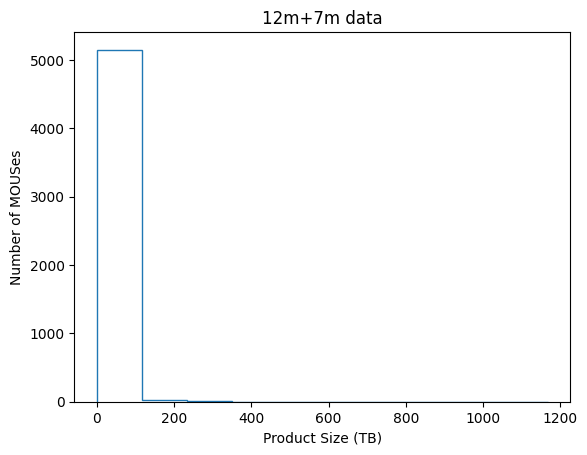

In [14]:
plt.hist(wsu_all['wsu_productsize_goal_stepped2'].to('TB').value,histtype='step',align='mid')
plt.xlabel('Product Size (TB)')
plt.ylabel('Number of MOUSes')
plt.title('12m+7m data')

Text(0.5, 1.0, '12m+7m data')

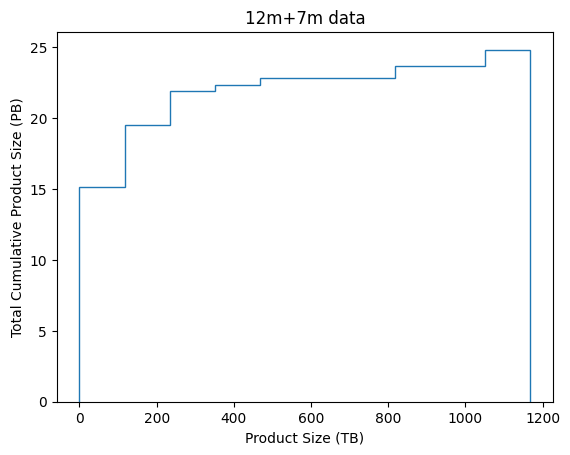

In [15]:
## by setting the weights to the value in PB, we can get the cumulative sum over all the data. 
plt.hist(wsu_all['wsu_productsize_goal_stepped2'].to('TB').value,
        weights=wsu_all['wsu_productsize_goal_stepped2'].to('PB').value, 
        cumulative=True,density=False,histtype='step',align='mid')
plt.xlabel('Product Size (TB)')
plt.ylabel('Total Cumulative Product Size (PB)')
plt.title('12m+7m data')

Text(0.5, 1.0, '7m data only')

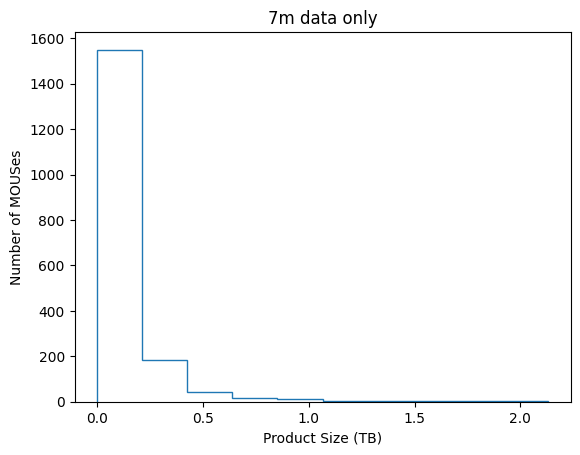

In [16]:
## plotting only 7m data
idx = wsu_all['array'] == '7m'
plt.hist(wsu_all[idx]['wsu_productsize_goal_stepped2'].to('TB').value,histtype='step',align='mid')
plt.xlabel('Product Size (TB)')
plt.ylabel('Number of MOUSes')
plt.title('7m data only')

In [22]:
m1prodSizeGb=wsu_all['wsu_productsize_initial_stepped2'].to('GB')


In [23]:
np.median(m1prodSizeGb)

<Quantity 13.21128 Gbyte>

In [24]:
np.max(m1prodSizeGb)

<Quantity 438006.6767664 Gbyte>

In [26]:
np.sum(m1prodSizeGb) / 1000 / 1000 / 2

<Quantity 4.44963194 Gbyte>

In [27]:
?m1prodSizeGb

Type:        Quantity
String form: [10.2003968 11.1476736 11.1476736 ...  0.4059072  0.4012416  0.0445824] Gbyte
Length:      5192
File:        ~/venv/env3/lib/python3.9/site-packages/astropy/units/quantity.py
Docstring:  
A `~astropy.units.Quantity` represents a number with some associated unit.

See also: https://docs.astropy.org/en/stable/units/quantity.html

Parameters
----------
value : number, `~numpy.ndarray`, `~astropy.units.Quantity` (sequence), or str
    The numerical value of this quantity in the units given by unit.  If a
    `Quantity` or sequence of them (or any other valid object with a
    ``unit`` attribute), creates a new `Quantity` object, converting to
    `unit` units as needed.  If a string, it is converted to a number or
    `Quantity`, depending on whether a unit is present.

unit : unit-like
    An object that represents the unit associated with the input value.
    Must be an `~astropy.units.UnitBase` object or a string parseable by
    the :mod:`~astropy.uni

In [28]:
q2 = m1prodSizeGb.copy()

In [29]:
limit = (100 * u.Gbyte).to(q2.unit)     # 100 Gbyte in q2's units (safe if units differ)
q2[q2 > limit] = limit

In [34]:
q2.sum() / 1000 / 1000 / 2

<Quantity 0.10286913 Gbyte>

In [35]:
?wsu_all

Type:        QTable
String form:
mous          ...
           ...
           ---------------------- ...
           uid://A001/X1465 <...> uid://A001/X2dfa/X81 ...
           uid://A001/X2dfa/X85 ...
           uid://A001/X2dfa/X8b ...
           Length = 5192 rows
Length:      5192
File:        ~/venv/env3/lib/python3.9/site-packages/astropy/table/table.py
Docstring:  
A class to represent tables of heterogeneous data.

`~astropy.table.QTable` provides a class for heterogeneous tabular data
which can be easily modified, for instance adding columns or new rows.

The `~astropy.table.QTable` class is identical to `~astropy.table.Table`
except that columns with an associated ``unit`` attribute are converted to
`~astropy.units.Quantity` objects.

For more information see:

- https://docs.astropy.org/en/stable/table/
- https://docs.astropy.org/en/stable/table/mixin_columns.html

Parameters
----------
data : numpy ndarray, dict, list, table-like object, optional
    Data to initialize table.


In [36]:
np.mean(wsu_all['ntarget'])


4.303351309707242

In [37]:
np.mean(wsu_all('nspw_initial'))


TypeError: 'QTable' object is not callable